# Forest Sketch scaling benchmarks

This notebook measures how Forest Sketch scales with the number of samples and input features. It records wall-clock time, process CPU time, and peak memory. The benchmark intentionally uses a small, single-threaded forest so the curves are reproducible on a laptop.

The experiment measures `fit_transform`, which includes the initial projection, every forest/path extraction stage, and the final projection. Dataset generation is excluded from the timed region.

In [1]:
import gc
import importlib.util
import os
import threading
import time
import tracemalloc

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier

from forestsketch import ForestSketchEstimator

RANDOM_STATE = 42
N_COMPONENTS = 32
N_ITERATIONS = 2
N_ESTIMATORS = 20

HAS_PSUTIL = importlib.util.find_spec("psutil") is not None
if HAS_PSUTIL:
    import psutil

def current_rss_mb():
    if not HAS_PSUTIL:
        return np.nan
    return psutil.Process(os.getpid()).memory_info().rss / 2**20

def benchmark_case(n_samples, n_features, sweep, seed):
    n_informative = max(2, min(n_features - 1, n_features // 2))
    X, y = make_classification(
        n_samples=n_samples,
        n_features=n_features,
        n_informative=n_informative,
        n_redundant=0,
        n_repeated=0,
        n_classes=2,
        random_state=seed,
    )
    sketch = ForestSketchEstimator(
        estimator=RandomForestClassifier(
            n_estimators=N_ESTIMATORS,
            max_depth=8,
            n_jobs=1,
            random_state=seed,
        ),
        n_components=N_COMPONENTS,
        n_iterations=N_ITERATIONS,
        random_state=seed,
    )

    gc.collect()
    rss_before = current_rss_mb()
    peak_rss = [rss_before]
    stop_sampling = threading.Event()

    def sample_rss():
        while not stop_sampling.wait(0.01):
            rss = current_rss_mb()
            if not np.isnan(rss):
                peak_rss[0] = max(peak_rss[0], rss)

    sampler = threading.Thread(target=sample_rss, daemon=True)
    tracemalloc.start()
    sampler.start()
    wall_start = time.perf_counter()
    cpu_start = time.process_time()
    X_sketch = sketch.fit_transform(X, y)
    cpu_seconds = time.process_time() - cpu_start
    wall_seconds = time.perf_counter() - wall_start
    stop_sampling.set()
    sampler.join()
    _, peak_python_bytes = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    return {
        "sweep": sweep,
        "n_samples": n_samples,
        "n_features": n_features,
        "wall_clock_seconds": wall_seconds,
        "cpu_seconds": cpu_seconds,
        "peak_python_mb": peak_python_bytes / 2**20,
        "peak_rss_mb": peak_rss[0],
        "rss_delta_mb": peak_rss[0] - rss_before if not np.isnan(peak_rss[0]) else np.nan,
        "output_nbytes": X_sketch.nbytes,
        "output_nonzeros": int(np.count_nonzero(X_sketch)),
    }

## Run the scaling grid

The sample sweep holds the feature count at 32. The feature sweep holds the sample count at 512. Increase these ranges for a larger study, but expect runtime and memory use to grow accordingly.

In [2]:
sample_sizes = [256, 512, 1024, 2048]
feature_sizes = [16, 32, 64, 128]

records = []
for index, n_samples in enumerate(sample_sizes):
    records.append(benchmark_case(n_samples, 32, "samples", RANDOM_STATE + index))
for index, n_features in enumerate(feature_sizes):
    records.append(benchmark_case(512, n_features, "features", RANDOM_STATE + 100 + index))

results = pd.DataFrame(records)
results["output_mb"] = results["output_nbytes"] / 2**20
results

/Users/f.costa/.venvs/py312/lib/python3.12/site-packages/sklearn/random_projection.py:411: DataDimensionalityWarning: The number of components is higher than the number of features: n_features < n_components (16 < 32).The dimensionality of the problem will not be reduced.
  warnings.warn(


,sweep,n_samples,n_features,wall_clock_seconds,cpu_seconds,peak_python_mb,peak_rss_mb,rss_delta_mb,output_nbytes,output_nonzeros,output_mb
0,samples,256,32,0.155580,0.155386,2.575020,230.765625,1.718750,65536,8192,0.0625
1,samples,512,32,0.166553,0.166905,5.347046,234.078125,3.250000,131072,16384,0.1250
2,samples,1024,32,0.196716,0.196170,10.612755,240.093750,5.953125,262144,32768,0.2500
3,samples,2048,32,0.277909,0.276092,20.783210,253.906250,12.187500,524288,65536,0.5000
4,features,512,16,0.177202,0.165119,5.242126,254.093750,0.218750,131072,16384,0.1250
5,features,512,32,0.162909,0.163338,5.444147,254.140625,0.062500,131072,16384,0.1250
6,features,512,64,0.163635,0.163837,5.456901,254.281250,0.171875,131072,16384,0.1250
7,features,512,128,0.221724,3.794052,5.550672,258.718750,4.000000,131072,16384,0.1250


In [3]:
display(
    results[
        [
            "sweep",
            "n_samples",
            "n_features",
            "wall_clock_seconds",
            "cpu_seconds",
            "peak_python_mb",
            "peak_rss_mb",
            "output_mb",
        ]
    ].round(3)
)

,sweep,n_samples,n_features,wall_clock_seconds,cpu_seconds,peak_python_mb,peak_rss_mb,output_mb
0,samples,256,32,0.156,0.155,2.575,230.766,0.062
1,samples,512,32,0.167,0.167,5.347,234.078,0.125
2,samples,1024,32,0.197,0.196,10.613,240.094,0.250
3,samples,2048,32,0.278,0.276,20.783,253.906,0.500
4,features,512,16,0.177,0.165,5.242,254.094,0.125
5,features,512,32,0.163,0.163,5.444,254.141,0.125
6,features,512,64,0.164,0.164,5.457,254.281,0.125
7,features,512,128,0.222,3.794,5.551,258.719,0.125


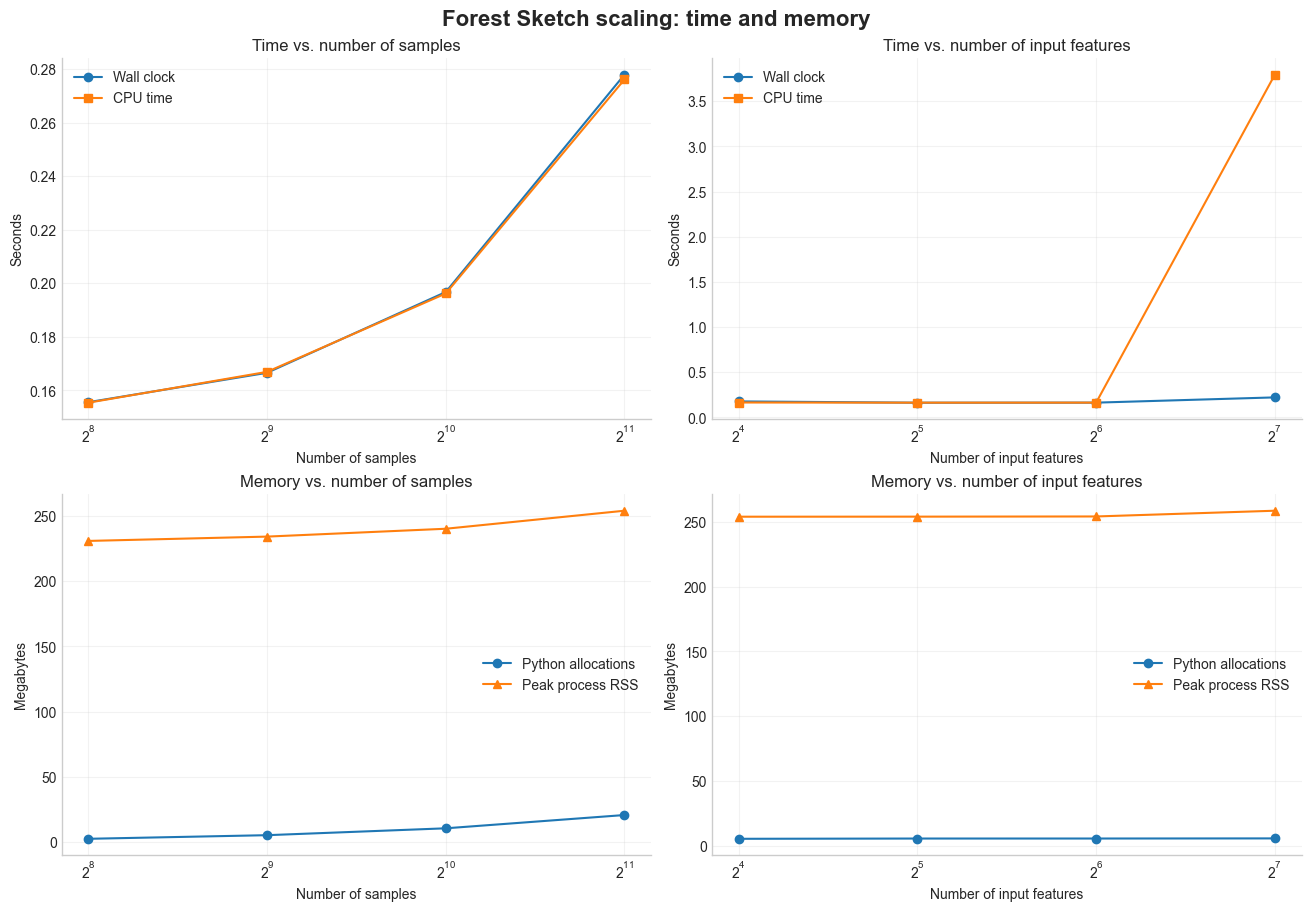

In [4]:
plt.style.use("seaborn-v0_8-whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)
fig.suptitle("Forest Sketch scaling: time and memory", fontsize=16, fontweight="bold")

sample_results = results[results["sweep"] == "samples"].sort_values("n_samples")
feature_results = results[results["sweep"] == "features"].sort_values("n_features")

axes[0, 0].plot(sample_results["n_samples"], sample_results["wall_clock_seconds"], marker="o", label="Wall clock")
axes[0, 0].plot(sample_results["n_samples"], sample_results["cpu_seconds"], marker="s", label="CPU time")
axes[0, 0].set_title("Time vs. number of samples")
axes[0, 0].set_xlabel("Number of samples")
axes[0, 0].set_ylabel("Seconds")
axes[0, 0].set_xscale("log", base=2)
axes[0, 0].legend()

axes[0, 1].plot(feature_results["n_features"], feature_results["wall_clock_seconds"], marker="o", label="Wall clock")
axes[0, 1].plot(feature_results["n_features"], feature_results["cpu_seconds"], marker="s", label="CPU time")
axes[0, 1].set_title("Time vs. number of input features")
axes[0, 1].set_xlabel("Number of input features")
axes[0, 1].set_ylabel("Seconds")
axes[0, 1].set_xscale("log", base=2)
axes[0, 1].legend()

axes[1, 0].plot(sample_results["n_samples"], sample_results["peak_python_mb"], marker="o", label="Python allocations")
if sample_results["peak_rss_mb"].notna().any():
    axes[1, 0].plot(sample_results["n_samples"], sample_results["peak_rss_mb"], marker="^", label="Peak process RSS")
axes[1, 0].set_title("Memory vs. number of samples")
axes[1, 0].set_xlabel("Number of samples")
axes[1, 0].set_ylabel("Megabytes")
axes[1, 0].set_xscale("log", base=2)
axes[1, 0].legend()

axes[1, 1].plot(feature_results["n_features"], feature_results["peak_python_mb"], marker="o", label="Python allocations")
if feature_results["peak_rss_mb"].notna().any():
    axes[1, 1].plot(feature_results["n_features"], feature_results["peak_rss_mb"], marker="^", label="Peak process RSS")
axes[1, 1].set_title("Memory vs. number of input features")
axes[1, 1].set_xlabel("Number of input features")
axes[1, 1].set_ylabel("Megabytes")
axes[1, 1].set_xscale("log", base=2)
axes[1, 1].legend()

for axis in axes.flat:
    axis.grid(True, which="both", alpha=0.25)
    axis.spines[["top", "right"]].set_visible(False)

plt.show()

## Reading the curves

Use wall-clock time for user-facing latency and CPU time for compute cost. `peak_python_mb` comes from `tracemalloc`; when `psutil` is available, `peak_rss_mb` captures the process-level resident-memory high-water mark during each case. These measurements are for relative scaling comparisons, not a substitute for a production workload profile.